In [ ]:
import numpy as np
import bilby
import h5py
import matplotlib.pyplot as plt
import tqdm
import plotfancy as pf
from scipy.signal import butter, filtfilt
from scipy import signal
from gwpy.timeseries import TimeSeries 
from gwpy.signal import filter_design
from gwpy.detector import ChannelList
from gwpy.time import to_gps

pf.housestyle_rcparams()

ifos = bilby.gw.detector.InterferometerList(['H1', 'L1', 'V1']) 
ifos.set_strain_data_from_zero_noise(
            sampling_frequency=1024.0,
            duration=8.0,
            start_time=1384782888.634277 - 6.,
        )
h_white_waveform = {ifo.name: [] for ifo in ifos}
h_white_waveform_fd = {ifo.name: [] for ifo in ifos}

model = 'SEOBNRv5PHM'
archive = h5py.File('dat/posterior_samples.h5')
posterior = archive.get('C00:'+model)['posterior_samples']


/Users/thardy/.local/share/mamba/envs/cam_venv/lib/python3.9/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [2]:
if model == "SEOBNRv5PHM":
    fd_model = bilby.gw.source.gwsignal_binary_black_hole
    waveform_arguments = {}
elif model == "IMRPhenomXPHM":
    fd_model = bilby.gw.source.lal_binary_black_hole
    waveform_arguments = {'PhenomXHMReleaseVersion': 122022, 'PhenomXPFinalSpinMod': 2, 'PhenomXPrecVersion': 320}
else:
    fd_model = bilby.gw.source.lal_binary_black_hole
    waveform_arguments = {}

waveform_arguments.update(
    {
        "waveform_approximant": model,
        "minimum_frequency": 10,
        "maximum_frequency": 448.0,
        "reference_frequency": 10,
    }
)
waveform_generator = bilby.gw.WaveformGenerator(
    duration=8.0, sampling_frequency=1024.0,
    frequency_domain_source_model=fd_model,
    start_time=1384782888.634277 - 6.,
    waveform_arguments=waveform_arguments
)

parameter_names = posterior.dtype.names
n_samples = len(posterior)
inds = np.arange(n_samples)

for ii in tqdm.tqdm(inds):
    if ii<100:
        params = {key: posterior[key][ii] for key in parameter_names}
        
        pols = waveform_generator.frequency_domain_strain(parameters=params)
        for ifo in ifos:
            h = ifo.get_detector_response(pols, params)
            frequency_window_factor = (
                np.sum(ifo.frequency_mask)
                / len(ifo.frequency_mask)
            )
            ht = h / (ifo.amplitude_spectral_density_array * np.sqrt(ifo.duration / 4))
            h_white_waveform[ifo.name].append(
                np.fft.irfft(ht)
                * np.sqrt(np.sum(ifo.frequency_mask)) / frequency_window_factor
            )
            h_white_waveform_fd[ifo.name].append(ht)


01:52 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.gwsignal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
100%|██████████| 17939/17939 [00:25<00:00, 703.75it/s]


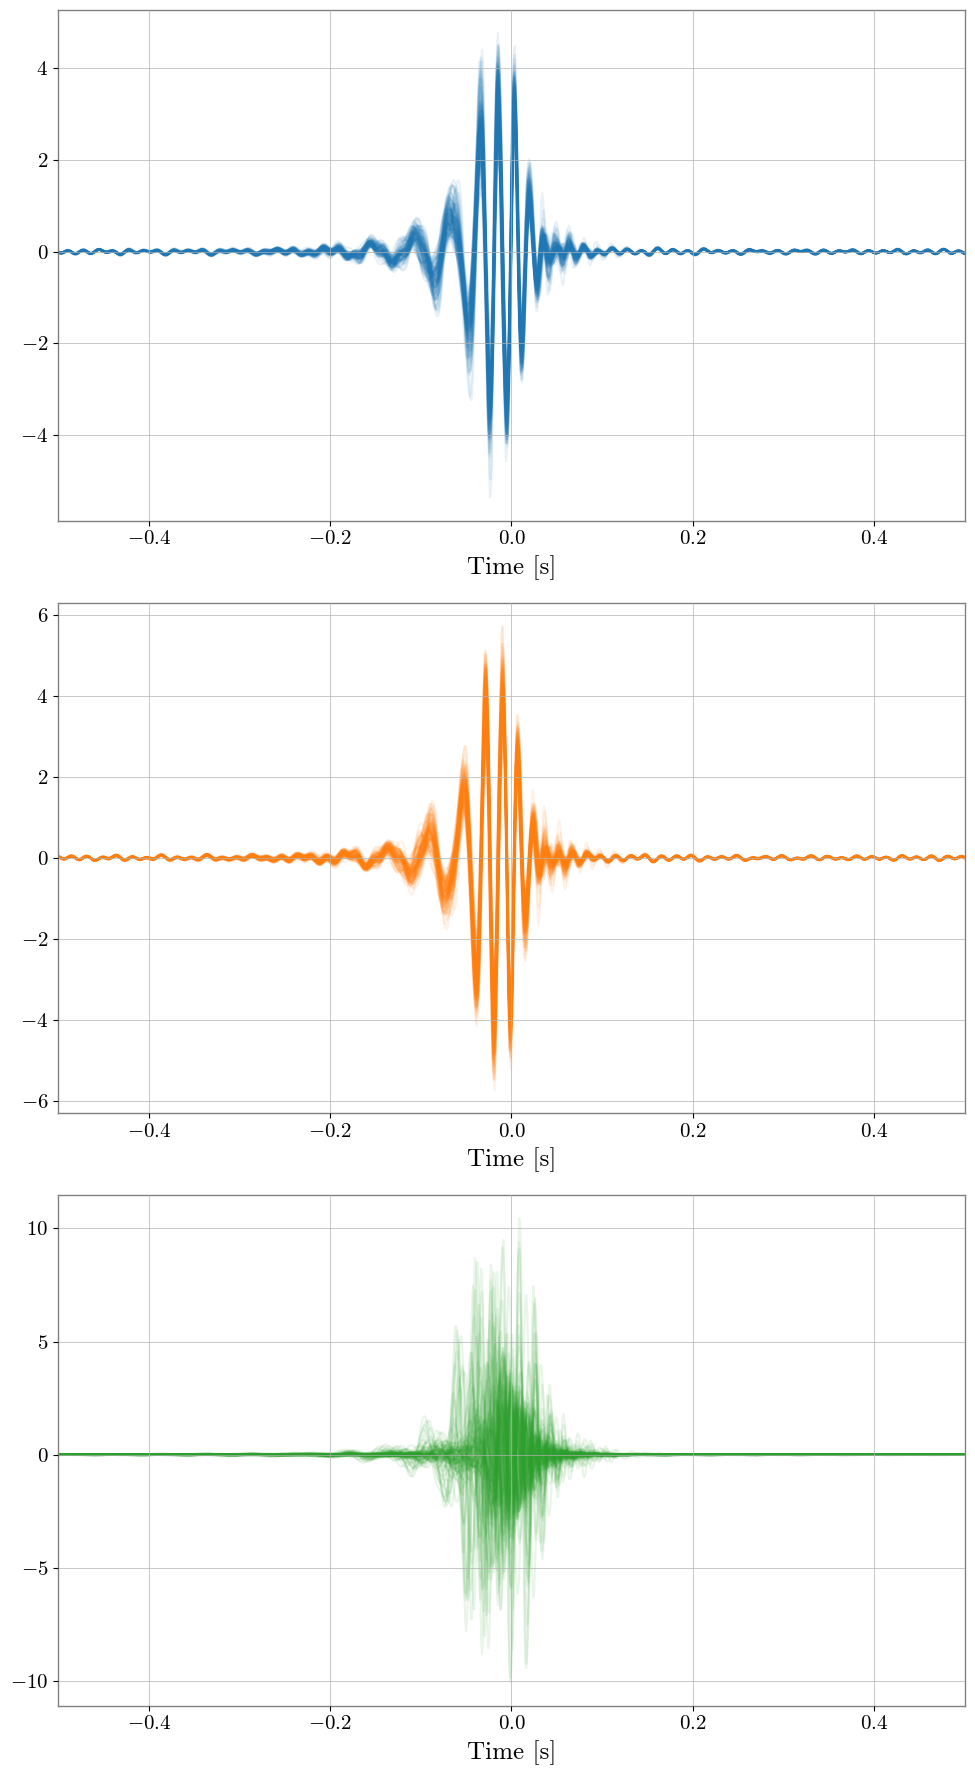

In [3]:
fig = plt.figure(figsize=(10, 18))

ax = plt.subplot(3, 1, 1)
for data in h_white_waveform["H1"]:
    plt.plot(np.linspace(-6, 2, len(data)), data, color="C0", alpha=0.1)
    plt.xlim(-6.0, 2.0)
    plt.xlim(-0.5, 0.5)
    plt.xlabel("Time [s]")

ax = plt.subplot(3, 1, 2)
for data in h_white_waveform["L1"]:
    plt.plot(np.linspace(-6, 2, len(data)), data, color="C1", alpha=0.1)
    plt.xlim(-6.0, 2.0)
    plt.xlim(-0.5, 0.5)
    plt.xlabel("Time [s]")

ax = plt.subplot(3, 1, 3)
for data in h_white_waveform["V1"]:
    plt.plot(np.linspace(-6, 2, len(data)), data, color="C2", alpha=0.1)
    plt.xlim(-6.0, 2.0)
    plt.xlim(-0.5, 0.5)
    plt.xlabel("Time [s]")
plt.tight_layout()

In [4]:

hdata = TimeSeries.read("dat/H1_HOFT_C00_BAYESWAVE_S00-1384782888.gwf", "H1:GDS-CALIB_STRAIN_CLEAN_BAYESWAVE_S00")

(-4.0, 4.0)

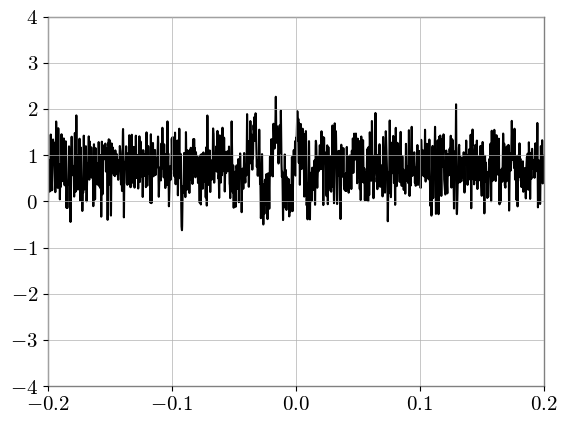

In [5]:
bp = filter_design.bandpass(20, 256, hdata.sample_rate)
notches = [filter_design.notch(line, hdata.sample_rate) for line in (60, 120, 180)]
zpk = filter_design.concatenate_zpks(bp, *notches)
hfilt = hdata.filter(zpk, filtfilt=True)
hfilt = hfilt.whiten(fduration=4)
plt.plot(hfilt.times.value - 1384782888.634277, hfilt.value, color='k')
plt.xlim(-0.2, 0.2)
plt.ylim(-4.0, 4.0)

In [6]:
whitened = {'H1': 'dat/BayesWave_whitened_data_H1.dat',
                 'L1': 'dat/BayesWave_whitened_data_L1.dat'}

sampling_frequency = 1024  # Hz
duration = 8  # seconds
start_time = 1384782882.634277105 #2023-11-23T13:54:24
ifos_names = ['H1', 'L1']

num_samples = int(sampling_frequency * duration)
time_array = start_time + np.arange(num_samples) / sampling_frequency

def lowpass_filter(data, lowpass_frequency=256, sampling_frequency=1024, order=4):
    nyquist = 0.5 * sampling_frequency
    normal_cutoff = lowpass_frequency / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

# Load and filter data
whitened_data = {
    ifo: {
        "time": time_array,
        "strain": lowpass_filter(np.genfromtxt(whitened[ifo]))
    }
    for ifo in ifos_names
}

s = 1384782888.634277

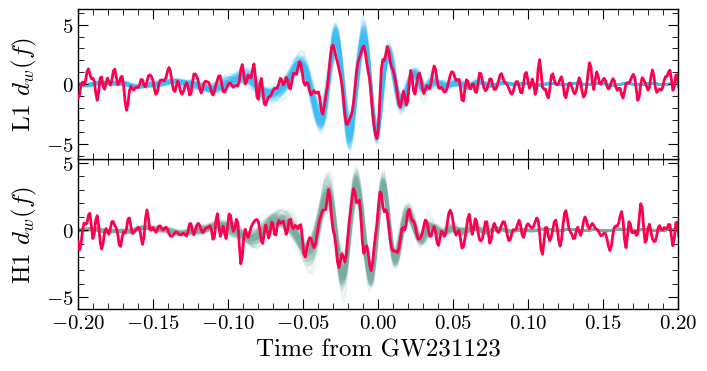

In [7]:
pf.housestyle_rcparams()
fig, ax = pf.create_plot(size=(6,1.5))
ax2 = fig.add_axes((0,1,1,1), sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)
axes = [ax,ax2]

ax.set_xlim(-0.2, 0.2)
ax.set_xlabel('Time from GW231123')

colors = ['#77aca2', "#38bdf7"]



for i,a in enumerate(axes):
    a.plot(whitened_data[ifos_names[i]]['time']-s,whitened_data[ifos_names[i]]['strain'], lw=2, color='#ff004f', zorder=10)
    a.set_ylabel(ifos_names[i]+r' $d_w(f)$')

    for data in h_white_waveform[ifos_names[i]]:
        a.plot(np.linspace(-6, 2, len(data)), data, color=colors[i], alpha=0.1)

pf.fix_plot([ax,ax2])
plt.savefig(f'figs/GW231123tdomain.png', dpi=700, bbox_inches = 'tight')

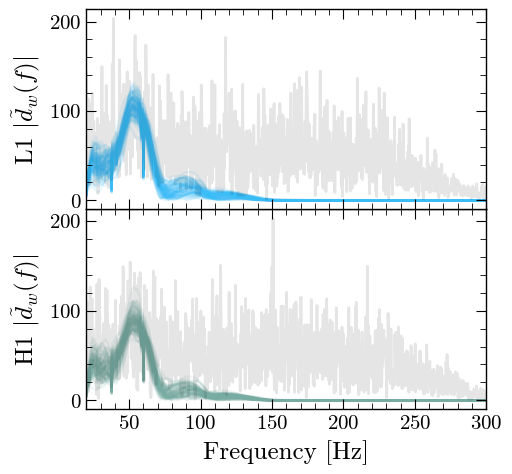

In [8]:
fftwindow = 4
fig, ax = pf.create_plot(size=(4,2))
ax2 = fig.add_axes((0,1,1,1), sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)
axes = [ax,ax2]
ax.set_xlim(20, 300)
ax.set_xlabel('Frequency [Hz]')

for i,a in enumerate(axes):
    # a.plot(whitened_data[ifos_names[i]]['time']-s,whitened_data[ifos_names[i]]['strain'], lw=2, color='#ff004f', zorder=10)
    # a.set_ylabel(ifos_names[i]+r' $d_w(f)$')

    # for data in h_white_waveform[ifos_names[i]]:
    #     a.plot(np.linspace(-6, 2, len(data)), data, color=colors[i], alpha=0.1)

    mask = (whitened_data[ifos_names[i]]['time']-s>-fftwindow/2)&(whitened_data[ifos_names[i]]['time']-s<fftwindow/2)
    chop = whitened_data[ifos_names[i]]['strain'][mask]

    delta_t=np.mean(np.diff(whitened_data[ifos_names[i]]['time']))
    dw_fdomain = np.fft.rfft(chop)
    frequencies = np.fft.rfftfreq(chop.size,delta_t)
    a.plot(frequencies,np.abs(dw_fdomain), lw=2, color='k', zorder=10, alpha=0.1)
    a.set_ylabel(ifos_names[i]+r' $|\tilde{d}_w(f)|$')

    for data in h_white_waveform[ifos_names[i]]:
            times = np.linspace(-6, 2, len(data))
            mask_2 = (times>-fftwindow/2)&(times<fftwindow/2)
            chop_2 = data[mask_2]

            delta_t_2=np.mean(np.diff(times))
            dw_fdomain_2 = np.fft.rfft(chop_2)
            frequencies_2 = np.fft.rfftfreq(chop_2.size,delta_t_2)
            a.plot(frequencies_2,np.abs(dw_fdomain_2), color=colors[i], alpha=0.1)

pf.fix_plot(axes)

plt.savefig(f'figs/GW231123fdomain.png', dpi=700, bbox_inches = 'tight')

True

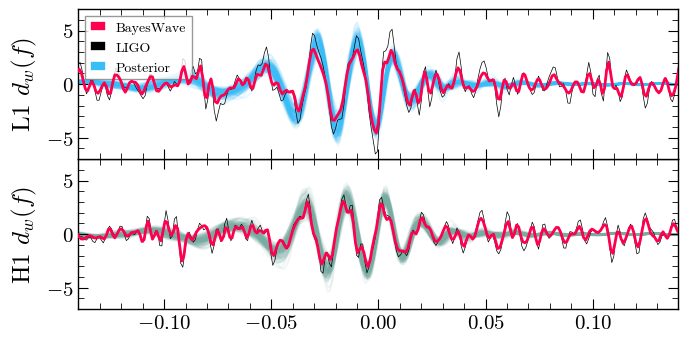

In [22]:
dat = [TimeSeries.read('dat/H-H1_GWOSC_O4a_4KHZ_R1-1384779776-4096.gwf', 'H1:GWOSC-4KHZ_R1_STRAIN'),
       TimeSeries.read('dat/L-L1_GWOSC_O4a_4KHZ_R1-1384779776-4096.gwf', 'L1:GWOSC-4KHZ_R1_STRAIN')]

tevent = 1384782888.634277
# window = 8

fig, ax = pf.create_plot(size=(6,1.5))
ax2 = fig.add_axes((0,1,1,1), sharex=ax,sharey=ax)
plt.setp(ax2.get_xticklabels(), visible=False)
axes = [ax,ax2]
ax.set_ylim(-7,7)
ax.set_xlim(-0.14,0.14)


for i,a in enumerate(axes):

    a.plot(whitened_data[ifos_names[i]]['time']-s,whitened_data[ifos_names[i]]['strain'], lw=2, color='#ff004f', zorder=10, label='BayesWave')
    a.set_ylabel(ifos_names[i]+r' $d_w(f)$')

    data = dat[i]
    tzero = data.t0.value
    dtevent = tevent-tzero

    data = data.resample(1024)
    data_white = data.whiten(window='tukey', fftlength=4, overlap=2)
    bp = filter_design.bandpass(20, 256, data_white.sample_rate)
    notches = [filter_design.notch(line, data_white.sample_rate) for line in (60, 120, 180)]
    zpk = filter_design.concatenate_zpks(bp, *notches)
    data_whiteFilt = data_white.filter(zpk, filtfilt=True)
    a.plot(np.array(data_whiteFilt.times)-tevent, 2*data_whiteFilt, color='k', linewidth=.5, label='LIGO')


    a.plot([-1000],[-1000],color=colors[i], label='Posterior' )

    for iii,data in enumerate(h_white_waveform[ifos_names[i]]):
        a.plot(np.linspace(-6, 2, len(data)), data, color=colors[i], alpha=0.1, zorder=-10)


ax2.legend(loc='upper left', fontsize=10,)


pf.fix_plot(axes)



In [14]:
np.mean(np.diff(whitened_data['L1']['time']))

0.0009765625

In [15]:
1/0.0009765625

1024.0

True

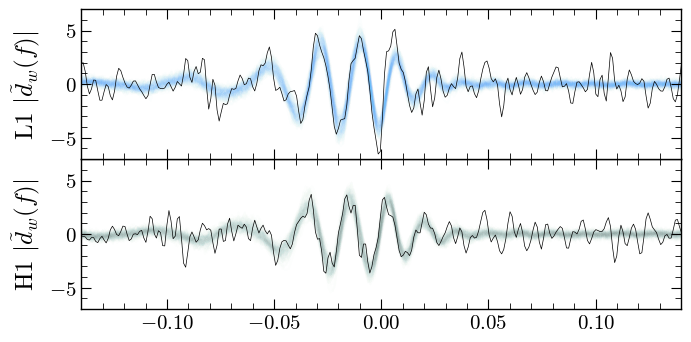

In [55]:
fig, ax = pf.create_plot(size=(6,1.5))
ax2 = fig.add_axes((0,1,1,1), sharex=ax,sharey=ax)
plt.setp(ax2.get_xticklabels(), visible=False)
axes = [ax,ax2]
ax.set_ylim(-7,7)
ax.set_xlim(-0.14,0.14)


for i,a in enumerate(axes):
    a.set_ylabel(ifos_names[i]+r' $|\tilde{d}_w(f)|$')

    data = dat[i]
    tzero = data.t0.value
    dtevent = tevent-tzero

    data = data.resample(1024)
    data_white = data.whiten(window='tukey', fftlength=4, overlap=2)
    bp = filter_design.bandpass(20, 256, data_white.sample_rate)
    notches = [filter_design.notch(line, data_white.sample_rate) for line in (60, 120, 180)]
    zpk = filter_design.concatenate_zpks(bp, *notches)
    data_whiteFilt = data_white.filter(zpk, filtfilt=True)
    a.plot(np.array(data_whiteFilt.times)-tevent, 2*data_whiteFilt, color='k', linewidth=.5, label='LIGO', zorder=10)

    for data in h_white_waveform_fd[ifos_names[i]]:
            test = data
            fgrid = np.linspace(10,448,4097)
            df = np.mean(np.diff(fgrid))
            factor = np.sqrt(df/2)
            noise = np.array(np.random.normal(loc = 0, scale = factor, size=test.shape)+1j*np.random.normal(loc = 0, scale = factor, size=test.shape))
            real = test+noise
            time_real = np.fft.irfft(real)* np.sqrt(np.sum(ifos[i].frequency_mask)) / frequency_window_factor
            a.plot(np.linspace(-6, 2, len(time_real)),time_real, color=colors[i], alpha=0.01)

pf.fix_plot(axes)

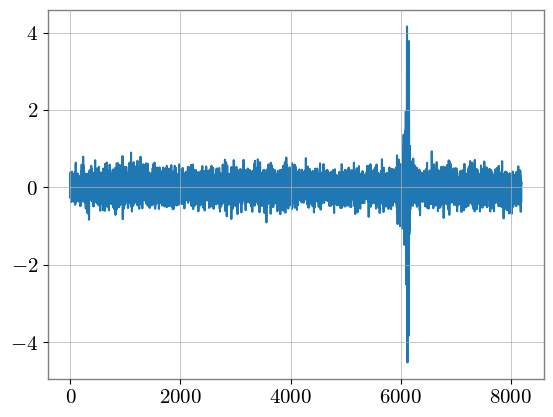

In [ ]:
test = h_white_waveform_fd['L1'][0]
fgrid = np.linspace(10,448,4097)
df = np.mean(np.diff(fgrid))
factor = np.sqrt(df/2)
noise = np.array(np.random.normal(loc = 0, scale = factor, size=test.shape)+1j*np.random.normal(loc = 0, scale = factor, size=test.shape))
real = test+noise
time_real = np.fft.irfft(real)* np.sqrt(np.sum(ifos[0].frequency_mask)) / frequency_window_factor
plt.plot(time_real)
